In [37]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
from google.colab import drive
drive.mount('/content/drive')
file_path='/content/Online Retail.xlsx'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_excel(file_path)
df.head(10)

In [40]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df['CustomerID']=df['CustomerID'].fillna(df['CustomerID'].mode()[0])
df['Description']=df['Description'].fillna(df['Description'].mode()[0])


In [42]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [43]:
df.duplicated().sum()

np.int64(5268)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  541909 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   541909 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [45]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [46]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
# df.info()

# Adding New Feature Revenue

In [47]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# EDA


In [48]:
revenue_per_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
display(revenue_per_country)

,Revenue
Country,
United Kingdom,8167128.184
Netherlands,284661.540
EIRE,262993.380
Germany,221509.470
France,197317.110
Australia,137009.770
Switzerland,56363.050
Spain,54756.030
Belgium,40910.960


/tmp/ipykernel_1597/2541162997.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='viridis')


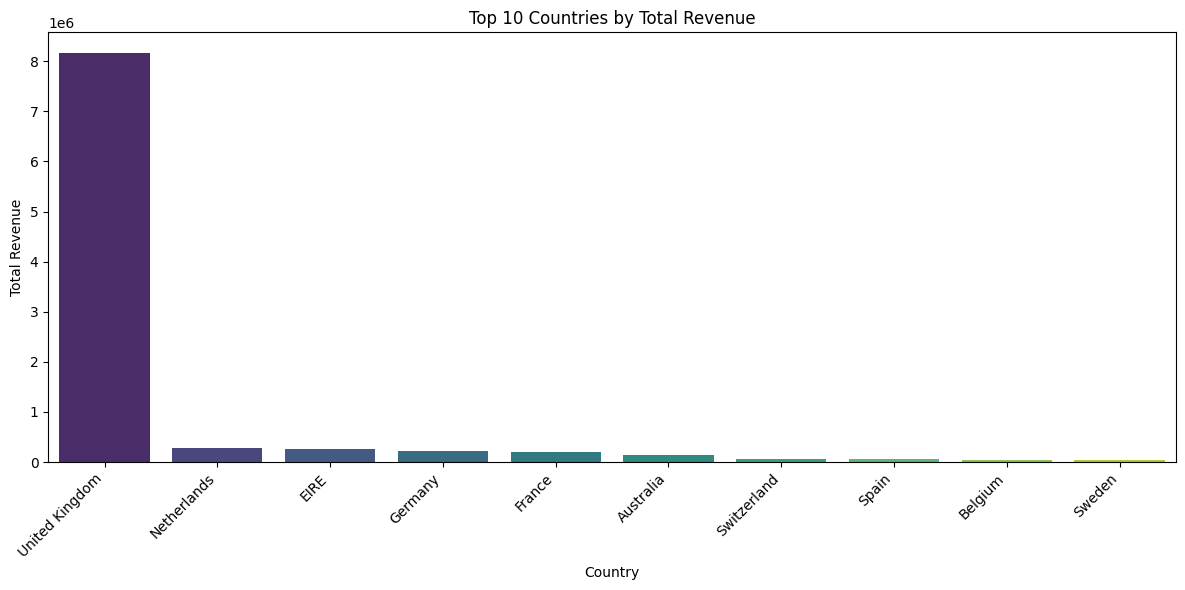

In [49]:
# Plotting top 10 countries by revenue
top_10_countries = revenue_per_country.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='viridis')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [50]:
# top product sold
top_products_by_quantity = df.groupby('Description')['Quantity'].sum().nlargest(5)
display(top_products_by_quantity)

,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,53751
JUMBO BAG RED RETROSPOT,47260
POPCORN HOLDER,36322
ASSORTED COLOUR BIRD ORNAMENT,36282
PACK OF 72 RETROSPOT CAKE CASES,36016


In [51]:
# Average revenue by countrypertransaction
average_revenue_per_transaction_by_country = df.groupby(['Country', 'InvoiceNo'])['Revenue'].sum().groupby('Country').mean().sort_values(ascending=False)
display(average_revenue_per_transaction_by_country)

,Revenue
Country,
Netherlands,2818.431089
Australia,1985.648841
Lebanon,1693.880000
Japan,1262.165000
Brazil,1143.600000
RSA,1002.310000
Singapore,912.039000
Denmark,893.720952
Norway,879.086500


In [52]:
country_summary = df.groupby('Country')[['Revenue']].describe()
display(country_summary)

Revenue                                              \
                         count        mean         std        min      25%   
Country                                                                      
Australia               1258.0  108.910787  159.069915    -425.00  16.5000   
Austria                  401.0   25.322494   34.579338     -21.25  13.5000   
Bahrain                   19.0   28.863158   73.816333    -205.74  17.7000   
Belgium                 2069.0   19.773301   15.583858     -19.95  12.7500   
Brazil                    32.0   35.737500   32.896282      15.00  16.5000   
Canada                   151.0   24.280662   61.117249       2.50  10.5000   
Channel Islands          757.0   26.520991   39.806049    -293.00  15.0000   
Cyprus                   611.0   21.045434   34.323191    -320.69  10.0400   
Czech Republic            30.0   23.590667   26.302604     -35.76  15.6000   
Denmark                  389.0   48.247147   72.244489     -59.80  13.9200   
EIRE                    8184.0   32.135066   95.039603   -1917.00  13.2000   
European Community        61.0   21.176230   11.514247      -8.50  15.0000   
Finland                  695.0   32.124806   49.169237     -80.00  13.5000   
France                  8541.0   23.102343  117.288622   -8322.12  10.5000   
Germany                 9480.0   23.365978   37.349011    -599.50  11.4000   
Greece                   146.0   32.263836   36.389952     -50.00  12.6250   
Hong Kong                284.0   34.888169  314.385798   -2653.95  15.0000   
Iceland                  182.0   23.681319   23.289902       5.04  13.2000   
Israel                   294.0   26.877449   35.801161    -136.00  10.2000   
Italy                    803.0   21.034259   21.850622     -89.55  14.3500   
Japan                    358.0   98.716816  311.427891   -1591.20   5.0400   
Lebanon                   45.0   37.641778   29.117840      10.20  17.0000   
Lithuania                 35.0   47.458857   23.824265      13.20  28.2000   
Malta                    127.0   19.728110   45.298451    -130.00  11.0500   
Netherlands             2371.0  120.059696  164.282504    -266.40  29.8500   
Norway                  1086.0   32.378877   46.936025    -376.50  15.0000   
Poland                   341.0   21.152903   16.198307     -39.80  14.8500   
Portugal                1510.0   19.405940   74.694059   -1241.98   9.9000   
RSA                       58.0   17.281207    6.490031       0.00  13.8275   
Saudi Arabia              10.0   13.117000   10.861336     -14.75  12.5850   
Singapore                229.0   39.827031  527.909692   -3949.32  16.8000   
Spain                   2528.0   21.659822   84.010451   -1715.85   9.9000   
Sweden                   461.0   79.360976  132.578397   -1188.00  15.0000   
Switzerland             1994.0   28.266324   35.892454    -179.00  12.5000   
USA                      291.0    5.948179   21.614088     -74.88 -13.2000   
United Arab Emirates      68.0   27.974706   24.413711       3.48  15.2250   
United Kingdom        490300.0   16.657410  396.909392 -168469.60   3.3000   
Unspecified              442.0   10.726109    9.550009       0.19   2.5500   

                                                  
                        50%       75%        max  
Country                                           
Australia             51.84  145.0000    1718.40  
Austria               17.00   22.5000     360.00  
Bahrain               25.50   34.8000     205.74  
Belgium               16.60   20.4000     165.00  
Brazil                19.65   47.4750     175.20  
Canada                16.50   19.8000     550.94  
Channel Islands       17.70   25.2000     408.00  
Cyprus                16.50   22.9500     320.69  
Czech Republic        25.30   39.7800      70.80  
Denmark               23.40   45.9000     428.40  
EIRE                  17.34   26.0250    2365.20  
European Community    17.70   24.9000      60.00  
Finland               17.85   31.6000     551.20  
France  

# Calculate Recency

In [56]:
# Set analysis date as one day after the last transaction
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
analysis_date

Timestamp('2011-12-10 12:50:00')

In [57]:
df_recency = df.groupby('CustomerID', as_index=False)['InvoiceDate'].max()
df_recency.columns = ['CustomerID', 'LastPurchaseDate']
df_recency.head()

,CustomerID,LastPurchaseDate
0,12346.0,2011-01-18 10:17:00
1,12347.0,2011-12-07 15:52:00
2,12348.0,2011-09-25 13:13:00
3,12349.0,2011-11-21 09:51:00
4,12350.0,2011-02-02 16:01:00


In [54]:
# calculae number of days since last purchase
current_date = df['InvoiceDate'].max()
df_recency['Recency'] = (current_date - df_recency['LastPurchaseDate']).dt.days
df_recency.head()

,CustomerID,LastPurchaseDate,Recency
0,12346.0,2011-01-18 10:17:00,325
1,12347.0,2011-12-07 15:52:00,1
2,12348.0,2011-09-25 13:13:00,74
3,12349.0,2011-11-21 09:51:00,18
4,12350.0,2011-02-02 16:01:00,309


# Frequency

In [63]:
df_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
df_frequency.columns = ['CustomerID', 'Frequency']
display(df_frequency.head())

,CustomerID,Frequency
0,12346.0,2
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [58]:
df_monetary = df.groupby('CustomerID')['Revenue'].sum().reset_index()
df_monetary.columns = ['CustomerID', 'Monetary']
display(df_monetary.head())

,CustomerID,Monetary
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [76]:
# Ensure df_recency has the 'Recency' column (number of days) before merging
current_date = df['InvoiceDate'].max()
df_recency['Recency'] = (current_date - df_recency['LastPurchaseDate']).dt.days

# Merge Recency, Frequency, and Monetary into one RFM table
rfm_table = df_recency.merge(df_frequency, on='CustomerID')
rfm_table = rfm_table.merge(df_monetary, on='CustomerID')

# Calculate Recency scores (5 for most recent, 1 for least recent)
rfm_table['R_Score'] = pd.qcut(rfm_table['Recency'], 5, labels=[5, 4, 3, 2, 1], duplicates='drop')

# Calculate Frequency scores (5 for highest frequency, 1 for lowest)
# Using .cat.codes + 1 to robustly assign scores based on actual number of unique quantiles
rfm_table['F_Score'] = pd.qcut(rfm_table['Frequency'], 5, duplicates='drop').cat.codes + 1

# Calculate Monetary scores (5 for highest monetary value, 1 for lowest)
# Using .cat.codes + 1 to robustly assign scores based on actual number of unique quantiles
rfm_table['M_Score'] = pd.qcut(rfm_table['Monetary'], 5, duplicates='drop').cat.codes + 1

display(rfm_table.head())

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346.0,2011-01-18 10:17:00,325,2,0.00,1,1,1
1,12347.0,2011-12-07 15:52:00,1,7,4310.00,5,3,5
2,12348.0,2011-09-25 13:13:00,74,4,1797.24,2,2,4
3,12349.0,2011-11-21 09:51:00,18,1,1757.55,4,1,4
4,12350.0,2011-02-02 16:01:00,309,1,334.40,1,1,2


Now that we have R, F, and M scores, let's combine them to create an overall RFM score and then define customer segments.

In [77]:
# Combine R, F, M scores to create an RFM segment string
rfm_table['RFM_Segment'] = rfm_table['R_Score'].astype(str) + rfm_table['F_Score'].astype(str) + rfm_table['M_Score'].astype(str)

# Calculate an overall RFM score (sum of R, F, M scores)
rfm_table['RFM_Score'] = rfm_table['R_Score'].astype(int) + rfm_table['F_Score'].astype(int) + rfm_table['M_Score'].astype(int)

display(rfm_table.head())

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,12346.0,2011-01-18 10:17:00,325,2,0.00,1,1,1,111,3
1,12347.0,2011-12-07 15:52:00,1,7,4310.00,5,3,5,535,13
2,12348.0,2011-09-25 13:13:00,74,4,1797.24,2,2,4,224,8
3,12349.0,2011-11-21 09:51:00,18,1,1757.55,4,1,4,414,9
4,12350.0,2011-02-02 16:01:00,309,1,334.40,1,1,2,112,4


### Define Customer Segments

In [78]:
def rfm_level(df):
    if df['RFM_Score'] >= 9:
        return 'Can\'t Loose Them'
    elif ((df['RFM_Score'] >= 8) and (df['RFM_Score'] < 9)):
        return 'Champions'
    elif ((df['RFM_Score'] >= 7) and (df['RFM_Score'] < 8)):
        return 'Loyal'
    elif ((df['RFM_Score'] >= 6) and (df['RFM_Score'] < 7)):
        return 'Potential'
    elif ((df['RFM_Score'] >= 5) and (df['RFM_Score'] < 6)):
        return 'Promising'
    elif ((df['RFM_Score'] >= 4) and (df['RFM_Score'] < 5)):
        return 'Needs Attention'
    else:
        return 'Require Activation'

rfm_table['Customer_Segment'] = rfm_table.apply(rfm_level, axis=1)

display(rfm_table.head())

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Customer_Segment
0,12346.0,2011-01-18 10:17:00,325,2,0.00,1,1,1,111,3,Require Activation
1,12347.0,2011-12-07 15:52:00,1,7,4310.00,5,3,5,535,13,Can't Loose Them
2,12348.0,2011-09-25 13:13:00,74,4,1797.24,2,2,4,224,8,Champions
3,12349.0,2011-11-21 09:51:00,18,1,1757.55,4,1,4,414,9,Can't Loose Them
4,12350.0,2011-02-02 16:01:00,309,1,334.40,1,1,2,112,4,Needs Attention


Let's look at the distribution of customers across these segments.

/tmp/ipykernel_1597/2779177079.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer_Segment', y='Count', data=segment_counts, palette='viridis')


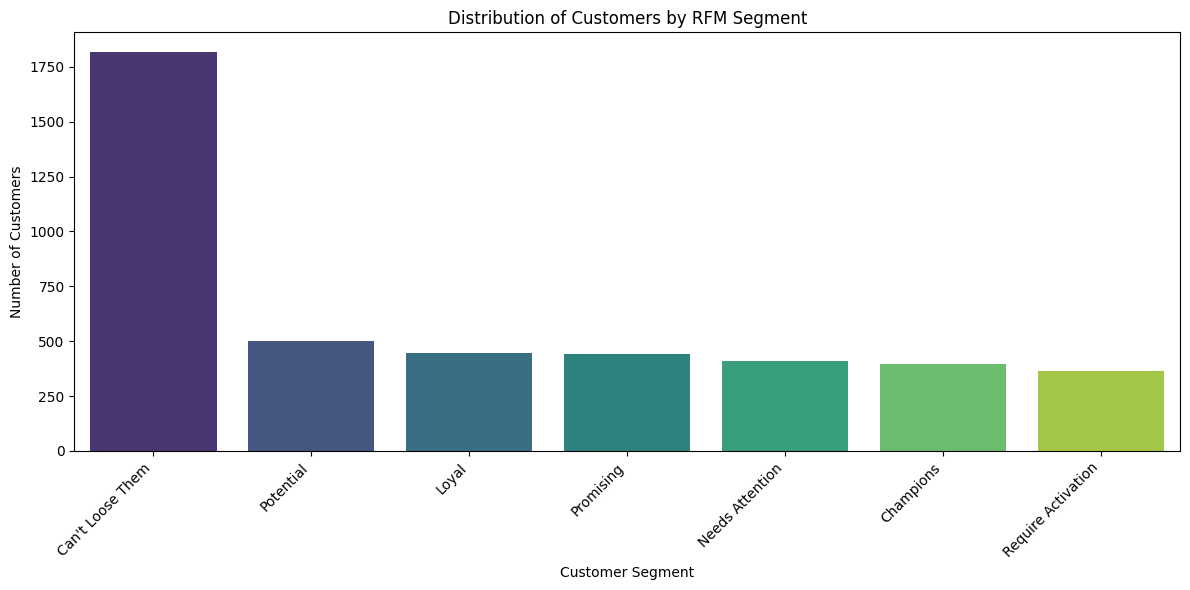

In [79]:
segment_counts = rfm_table['Customer_Segment'].value_counts().reset_index()
segment_counts.columns = ['Customer_Segment', 'Count']

plt.figure(figsize=(12, 6))
sns.barplot(x='Customer_Segment', y='Count', data=segment_counts, palette='viridis')
plt.title('Distribution of Customers by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Now that we have R, F, and M scores, let's combine them to create an overall RFM score and then define customer segments.

In [80]:
# Combine R, F, M scores to create an RFM segment string
rfm_table['RFM_Segment'] = rfm_table['R_Score'].astype(str) + rfm_table['F_Score'].astype(str) + rfm_table['M_Score'].astype(str)

# Calculate an overall RFM score (sum of R, F, M scores)
rfm_table['RFM_Score'] = rfm_table['R_Score'].astype(int) + rfm_table['F_Score'].astype(int) + rfm_table['M_Score'].astype(int)

display(rfm_table.head())

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Customer_Segment
0,12346.0,2011-01-18 10:17:00,325,2,0.00,1,1,1,111,3,Require Activation
1,12347.0,2011-12-07 15:52:00,1,7,4310.00,5,3,5,535,13,Can't Loose Them
2,12348.0,2011-09-25 13:13:00,74,4,1797.24,2,2,4,224,8,Champions
3,12349.0,2011-11-21 09:51:00,18,1,1757.55,4,1,4,414,9,Can't Loose Them
4,12350.0,2011-02-02 16:01:00,309,1,334.40,1,1,2,112,4,Needs Attention


### Define Customer Segments

In [81]:
def rfm_level(df):
    if df['RFM_Score'] >= 9:
        return 'Can\'t Loose Them'
    elif ((df['RFM_Score'] >= 8) and (df['RFM_Score'] < 9)):
        return 'Champions'
    elif ((df['RFM_Score'] >= 7) and (df['RFM_Score'] < 8)):
        return 'Loyal'
    elif ((df['RFM_Score'] >= 6) and (df['RFM_Score'] < 7)):
        return 'Potential'
    elif ((df['RFM_Score'] >= 5) and (df['RFM_Score'] < 6)):
        return 'Promising'
    elif ((df['RFM_Score'] >= 4) and (df['RFM_Score'] < 5)):
        return 'Needs Attention'
    else:
        return 'Require Activation'

rfm_table['Customer_Segment'] = rfm_table.apply(rfm_level, axis=1)

display(rfm_table.head())

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Customer_Segment
0,12346.0,2011-01-18 10:17:00,325,2,0.00,1,1,1,111,3,Require Activation
1,12347.0,2011-12-07 15:52:00,1,7,4310.00,5,3,5,535,13,Can't Loose Them
2,12348.0,2011-09-25 13:13:00,74,4,1797.24,2,2,4,224,8,Champions
3,12349.0,2011-11-21 09:51:00,18,1,1757.55,4,1,4,414,9,Can't Loose Them
4,12350.0,2011-02-02 16:01:00,309,1,334.40,1,1,2,112,4,Needs Attention


Let's look at the distribution of customers across these segments.

/tmp/ipykernel_1597/2779177079.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer_Segment', y='Count', data=segment_counts, palette='viridis')


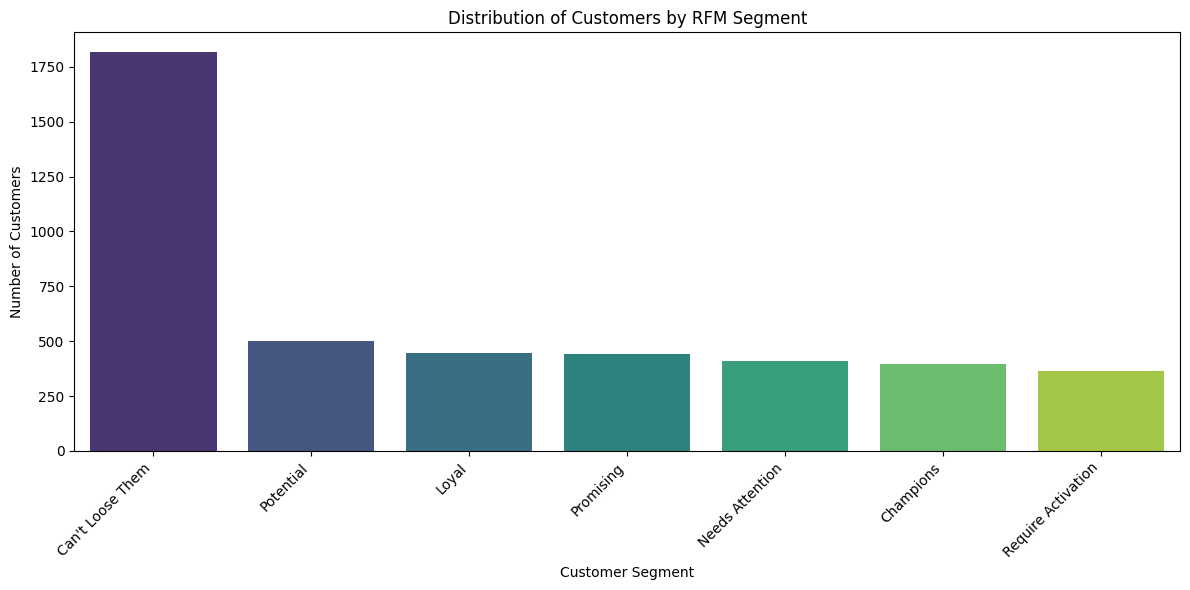

In [82]:
segment_counts = rfm_table['Customer_Segment'].value_counts().reset_index()
segment_counts.columns = ['Customer_Segment', 'Count']

plt.figure(figsize=(12, 6))
sns.barplot(x='Customer_Segment', y='Count', data=segment_counts, palette='viridis')
plt.title('Distribution of Customers by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# champion customer

In [83]:
champions_segment = rfm_table[rfm_table['Customer_Segment'] == 'Champions']
display(champions_segment[['Recency', 'Frequency', 'Monetary', 'RFM_Score']].describe())

,Recency,Frequency,Monetary,RFM_Score
count,394.000000,394.000000,394.000000,394.0
mean,57.497462,2.860406,927.401881,8.0
std,52.555423,1.382665,1331.521664,0.0
min,0.000000,1.000000,2.900000,8.0
25%,19.250000,2.000000,466.170000,8.0
50%,44.000000,3.000000,674.450000,8.0
75%,79.000000,4.000000,1046.652500,8.0
max,329.000000,9.000000,21535.900000,8.0


*  Recency: These customers have made a purchase relatively recently, with an average Recency of about 57 days. The minimum is 0 days, meaning some purchased yesterday, while the maximum is 329 days.
* Frequency: On average, Champions have made about 2.86 unique purchases, with some making up to 9 purchases.
*  Monetary: This segment shows a high average monetary value of approximately 927.40, with a significant maximum value of 21,535.90. This indicates that while the average is good, there are some very high-spending customers within this segment.
*  RFM_Score: All customers in this segment have an RFM score of 8.0, which aligns with our definition of 'Champions' (RFM_Score between 8 and 9).